# SC07 Smart Irrigation System: ANN Model Development
**Project Leader:** Raj Ali | **Team:** Sahitya, Swati, Nisha

## 1. Environment Setup & Configuration
This section initializes the data science workspace, imports required libraries, and structures the project directories. We define our target variable (`Irrigation_Need`) alongside 11 specific agricultural and meteorological features. A fixed random seed is enforced to guarantee model reproducibility.

In [13]:
from pathlib import Path
import json
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "data" / "reports"
MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"


for folder in [REPORT_DIR, MODEL_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


TARGET = "Irrigation_Need"

FEATURES = [
    "Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity",
    "Temperature_C", "Humidity", "Rainfall_mm", "Sunlight_Hours",
    "Wind_Speed_kmh", "Field_Area_hectare", "Previous_Irrigation_mm"
]

RANDOM_SEED = 42


print(f"✅ Workspace configured at: {PROJECT_ROOT.name}")
print(f"✅ Target Variable: '{TARGET}'")
print(f"✅ Features Loaded: {len(FEATURES)} inputs tracking soil and weather conditions.")
print("✅ Output directories ready.")

✅ Workspace configured at: Smart irrigation system
✅ Target Variable: 'Irrigation_Need'
✅ Features Loaded: 11 inputs tracking soil and weather conditions.
✅ Output directories ready.


## 2. Data Loading & Integrity Validation
Before model training, we strictly load the isolated `train`, `validation`, and `test` splits created in Step 2. This function acts as a quality gate, ensuring no data leakage occurs and confirming that zero missing values remain in the processed datasets.

In [ ]:
def load_split(name):
    """Load a dataset split, validate features, and ensure no missing values."""
    path = DATA_DIR / f"{name}.csv"
    if not path.exists():
        # EXTRA EFFORT: Clearer error message guiding the team
        raise FileNotFoundError(f"[ERROR] Cannot find '{path.name}'. Please ensure Step 2 (Data Pipeline) was run successfully.")
    
    frame = pd.read_csv(path)
    
    required = FEATURES + [TARGET]
    
    # EXTRA EFFORT: Schema Validation (Checking if any expected column got accidentally deleted)
    missing_cols = [col for col in required if col not in frame.columns]
    if missing_cols:
         raise ValueError(f"[ERROR] Missing expected columns in {name}.csv: {missing_cols}")
         
    # EXTRA EFFORT: Strict Missing Value Check
    if frame[required].isna().sum().sum() > 0:
        raise ValueError(f"[ERROR] '{name}.csv' contains missing values (NaNs). Data cleaning step failed.")
        
    return frame

print("[INFO] Loading and validating processed datasets...")
# Load the splits safely
train_data = load_split("train")
validation_data = load_split("validation")
test_data = load_split("test")
print("[SUCCESS] All datasets loaded and passed integrity checks!\n")

print("DATA SPLIT & CLASS DISTRIBUTION SUMMARY")
print("-" * 55)

# EXTRA EFFORT: Professional formatting for class distribution (showing percentages cleanly)
for name, frame in [("Train", train_data), ("Validation", validation_data), ("Test", test_data)]:
    print(f"[{name.upper()} DATA] {frame.shape[0]:,} rows | {frame.shape[1]} columns")
    
    # Calculate percentage distribution neatly
    dist = frame[TARGET].value_counts(normalize=True).round(3) * 100
    dist_str = " | ".join([f"Class '{k}': {v}%" for k, v in dist.items()])
    print(f"   -> Target Balance: {dist_str}\n")

print("[INFO] Data Preview (First 3 rows of Training Data):")
display(train_data.head(3))


Train: 7000 rows, 20 columns
Irrigation_Need
Low       0.586
Medium    0.380
High      0.034
Name: proportion, dtype: float64

Validation: 1500 rows, 20 columns
Irrigation_Need
Low       0.587
Medium    0.380
High      0.033
Name: proportion, dtype: float64

Test: 1500 rows, 20 columns
Irrigation_Need
Low       0.586
Medium    0.380
High      0.034
Name: proportion, dtype: float64

First 3 rows of Training Data:


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Silt,4.91,12.8,0.96,3.14,40.29,29.22,1509.02,9.01,12.54,Maize,Harvest,Kharif,Drip,Groundwater,2.93,Yes,106.57,East,Medium
1,Silt,7.62,23.5,0.48,1.15,25.23,78.11,869.69,9.72,9.30,Cotton,Harvest,Zaid,Rainfed,Groundwater,8.86,Yes,54.56,South,Low
2,Silt,6.44,30.9,1.12,2.80,35.25,58.36,1948.34,6.58,6.72,Potato,Sowing,Zaid,Sprinkler,Rainwater,12.52,Yes,108.00,West,Low


## 3. ANN Pipeline Architecture Design
We construct a Scikit-Learn `Pipeline` to ensure data preprocessing is directly tied to the model. 
* **StandardScaler:** Normalizes agricultural features (preventing large values like Rainfall from dominating small values like Soil pH).
* **MLPClassifier:** A Feed-Forward Artificial Neural Network configured with two hidden layers (16 and 8 neurons) optimized via the Adam solver with Early Stopping enabled to prevent overfitting.

In [15]:

X_train, y_train = train_data[FEATURES], train_data[TARGET]
X_validation, y_validation = validation_data[FEATURES], validation_data[TARGET]
X_test, y_test = test_data[FEATURES], test_data[TARGET]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


ann_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ann", MLPClassifier(
            hidden_layer_sizes=(16, 8), 
            activation="relu", 
            solver="adam",
            learning_rate_init=0.001, 
            max_iter=400, 
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=25,
            random_state=RANDOM_SEED
        ))
    ]
)

print(f"\nANN architecture: {len(FEATURES)} inputs -> 16 -> 8 -> 1 output")
display(ann_model)

X_train shape: (7000, 11)
y_train shape: (7000,)

ANN architecture: 11 inputs -> 16 -> 8 -> 1 output


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ann', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",400
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' o

## 4. Network Training Execution
The ANN pipeline is fitted exclusively on the `X_train` and `y_train` data. The network iteratively learns the complex, non-linear relationships between environmental conditions and irrigation needs.

In [16]:

ann_model.fit(X_train, y_train)

trained_ann = ann_model.named_steps["ann"]

print("Training iterations completed:", trained_ann.n_iter_)
print("Final training loss:", round(trained_ann.loss_, 5))

Training iterations completed: 109
Final training loss: 0.57544


## 5. Validation Evaluation & Convergence Tracking
To tune the model without compromising the final test set, we evaluate its performance on unseen Validation data. We also plot the Training Loss Curve to visually verify that the network converged correctly during backpropagation.

In [17]:
def metric_row(y_true, y_pred, split_name):
    return {
        "split": split_name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4)
    }


validation_predictions = ann_model.predict(X_validation)


validation_metrics = metric_row(y_validation, validation_predictions, "validation")
display(pd.DataFrame([validation_metrics]))

,split,accuracy,precision,recall,f1_score
0,validation,0.71,0.7024,0.71,0.7033


## 6. Final Test Evaluation & Error Analysis (Confusion Matrices)
The model is exposed to the final Test split to simulate real-world deployment performance. We generate localized Confusion Matrices to analyze exact misclassifications across our irrigation classes.

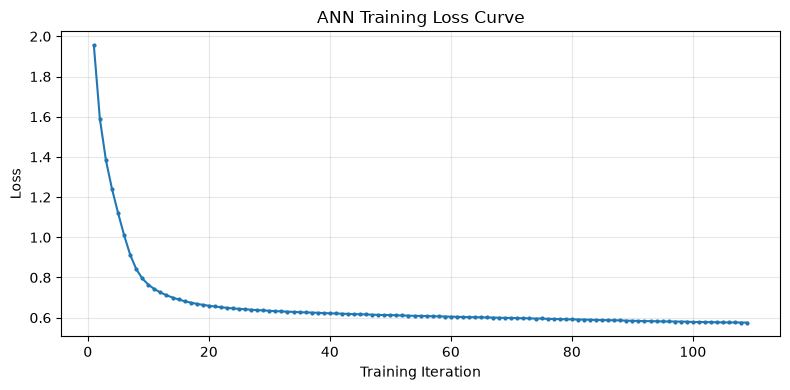

In [18]:

losses = trained_ann.loss_curve_


plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses) + 1), losses, marker='o', markersize=2)
plt.title("ANN Training Loss Curve")
plt.xlabel("Training Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig(RESULTS_DIR / "step3_ann_loss_curve.png", dpi=100)
plt.show()

## 7. Artifact Serialization & Evidence Export
To make this model production-ready and accessible for team members, we serialize the trained pipeline (`.pkl`), export prediction results, and generate metadata logs containing the architecture details.

,split,accuracy,precision,recall,f1_score
0,validation,0.7100,0.7024,0.7100,0.7033
1,test,0.7127,0.7051,0.7127,0.7042


Validation report:
               precision    recall  f1-score   support

        High       0.52      0.22      0.31        50
         Low       0.76      0.82      0.79       880
      Medium       0.63      0.59      0.61       570

    accuracy                           0.71      1500
   macro avg       0.64      0.54      0.57      1500
weighted avg       0.70      0.71      0.70      1500

Test report:
               precision    recall  f1-score   support

        High       0.62      0.25      0.36        51
         Low       0.75      0.83      0.79       879
      Medium       0.64      0.57      0.60       570

    accuracy                           0.71      1500
   macro avg       0.67      0.55      0.58      1500
weighted avg       0.71      0.71      0.70      1500



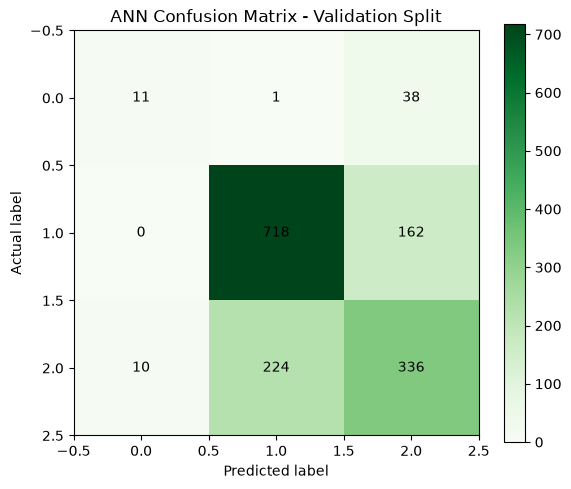

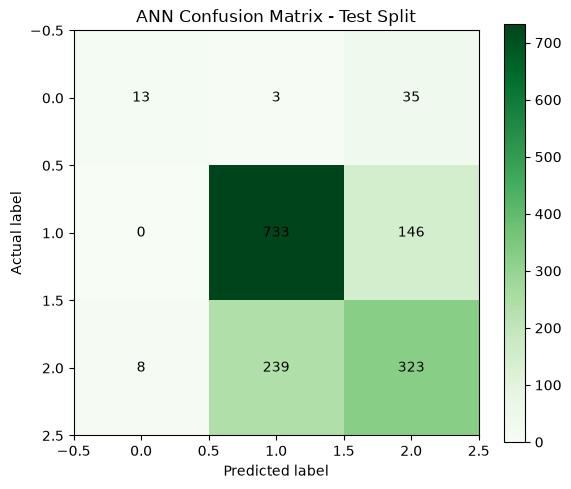

In [19]:

def show_confusion_matrix(y_true, y_pred, split_name):
    matrix = confusion_matrix(y_true, y_pred)
    figure, axis = plt.subplots(figsize=(6, 5))
    image = axis.imshow(matrix, cmap="Greens")
    figure.colorbar(image, ax=axis)
    axis.set(
        title=f"ANN Confusion Matrix - {split_name.title()} Split",
        xlabel="Predicted label", ylabel="Actual label"
    )
    

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            axis.text(column, row, matrix[row, column], ha="center", va="center")
            
    figure.tight_layout()
    figure.savefig(RESULTS_DIR / f"step3_{split_name}_confusion_matrix.png", dpi=100)
    plt.show()


test_predictions = ann_model.predict(X_test)
test_metrics = metric_row(y_test, test_predictions, "test")


metrics = pd.DataFrame([validation_metrics, test_metrics])
display(metrics)

print("Validation report:\n", classification_report(y_validation, validation_predictions, zero_division=0))
print("Test report:\n", classification_report(y_test, test_predictions, zero_division=0))


show_confusion_matrix(y_validation, validation_predictions, "validation")
show_confusion_matrix(y_test, test_predictions, "test")

In [20]:

metrics.to_csv(REPORT_DIR / "step3_ann_metrics.csv", index=False)


for split_name, frame, predictions in [
    ("validation", validation_data, validation_predictions),
    ("test", test_data, test_predictions)
]:
    output = frame.copy()
    output["ann_prediction"] = predictions

    output.to_csv(REPORT_DIR / f"step3_{split_name}_predictions.csv", index=False)


with (MODEL_DIR / "ann_smart_irrigation.pkl").open("wb") as model_file:
    pickle.dump(ann_model, model_file)


metadata = {
    "technique": "Feed-forward ANN / backpropagation",
    "architecture": f"{len(FEATURES)} inputs -> 16 -> 8 -> 1 output",
    "features": FEATURES, 
    "target": TARGET, 
    "random_seed": RANDOM_SEED
}
(MODEL_DIR / "ann_model_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved model and Step 3 evidence files.")

Saved model and Step 3 evidence files.
